# machine.ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = pd.read_csv('Wholesale customers data.csv')

X = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']]
y = df['Channel']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=0)

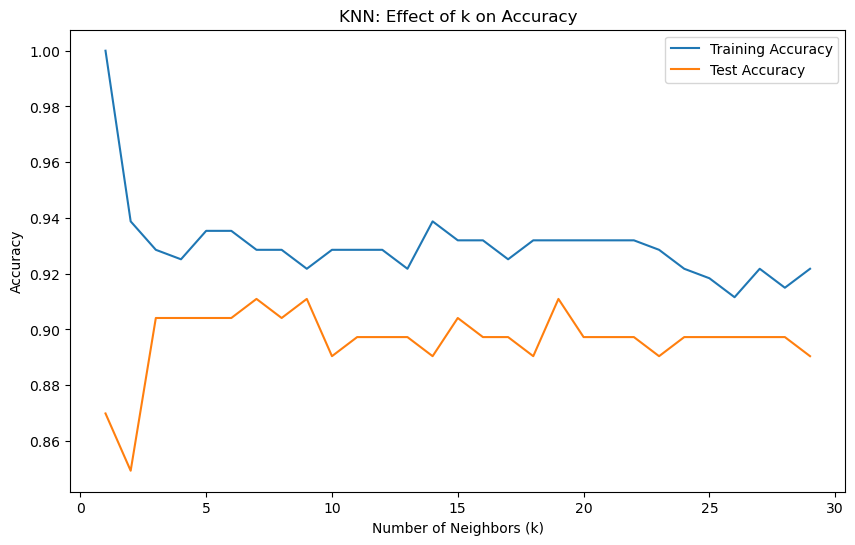

In [2]:
k_values = range(1, 30)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, label='Training Accuracy')
plt.plot(k_values, test_scores, label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Effect of k on Accuracy')
plt.legend()
plt.show()

In [3]:
best_k = k_values[np.argmax(test_scores)]
print(f"Best k is: {best_k}")

Best k is: 7


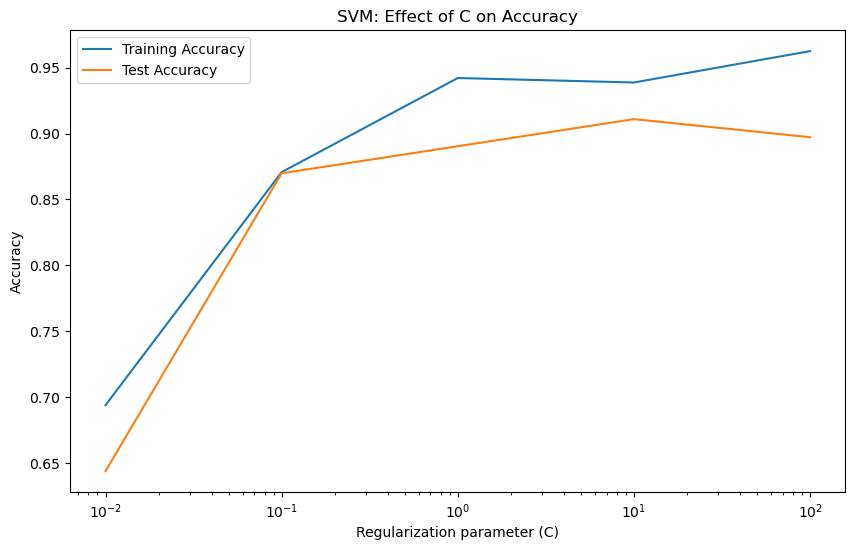

In [4]:
C_values = [0.01, 0.1, 1, 10, 100]
svm_train_scores = []
svm_test_scores = []

for C in C_values:
    svm = SVC(C=C, kernel='rbf', random_state=42)
    svm.fit(X_train, y_train)
    svm_train_scores.append(svm.score(X_train, y_train))
    svm_test_scores.append(svm.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.semilogx(C_values, svm_train_scores, label='Training Accuracy')
plt.semilogx(C_values, svm_test_scores, label='Test Accuracy')
plt.xlabel('Regularization parameter (C)')
plt.ylabel('Accuracy')
plt.title('SVM: Effect of C on Accuracy')
plt.legend()
plt.show()

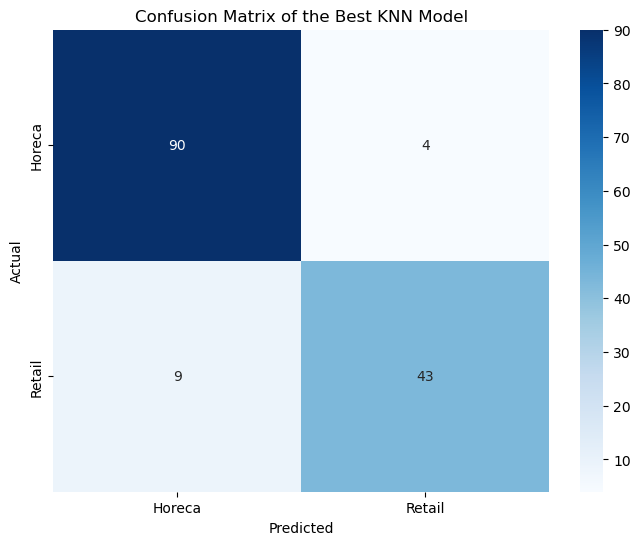

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Horeca', 'Retail'], 
            yticklabels=['Horeca', 'Retail'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the Best KNN Model')
plt.show()